# <span style="color:#0694cd"><strong>FarmTech Solutions:</strong></span> <span style="color:#0694cd">Demonstração de Visão Computacional com YOLO</span>
## **Desafio 1**

Criar um sistema de visão computacional usando YOLOv5 para detectar dois tipos de imagens distintas e demonstrar seu potencial e acurácia para um cliente.

**Etapas**
1.  **Configuração:** Definição de parametros globais, Clone de repositorio e Instalação de dependências.
2.  **Criação do Arquivo de referências:** Definir o arquivo `dataset.yaml` dinamicamente.
3.  **Treinamento:** Treinar o modelo YOLOv5 com duas configurações de épocas diferentes.
4.  **Teste (Inferência):** Executar imagens de teste com os modelos treinados.
5.  **Análise:** Comparar os resultados e tirar conclusões. Foram separadas 8 imagens relacionadas ao grupo A e 8 ao grupo B. O resultado mostrará a previsão de todas para todas as épocas usadas

**Observações**
1.  **Tipos:** Serão usados dois grupos de imagens. O primeiro grupo (grupo A, classe 0) serão imagens de cachorros. O Segundo grupo serão imagens de carros (grupo B, classe 1).
2.  **Quantidade:** Serão usadas 32 imagens de cada grupo para treino do modelo, 8 imagens de cada grupo para validação do modelo e 8 imagens de cada grupo para testes do modelo. Totalizando 96 imagens no projeto.
3.  **Bibliotecas:** Serão usados python 3.12.0 e YOLOv5 na demonstração

### <span style="color:#dfceb9">**1.** Configuração do Ambiente</span>

#### <span style="color:#57b7b4">**1.1** Definição de diretorios e Criação de variaveis globais</span>

In [1]:
import os, sys

BASE_PATH = os.getcwd()

IMAGES_TRAIN = f'{BASE_PATH}/images/train' # Diretório com imagens de treino
IMAGES_VAL = f'{BASE_PATH}/images/val' # Diretório com imagens de validação
IMAGES_TEST = f'{BASE_PATH}/images/test' # Diretório com imagens de teste
YAML_PATH = f'{BASE_PATH}/dataset.yaml'

TRAIN_PATH = f'{BASE_PATH}/runs-desafio_1/train'
VAL_PATH = f'{BASE_PATH}/runs-desafio_1/val'
TEST_PATH = f'{BASE_PATH}/runs-desafio_1/detect'

T1_FOLDER = 't1_model'
T1_PATH = f'{TRAIN_PATH}/{T1_FOLDER}'
V1_PATH = f'{VAL_PATH}/{T1_FOLDER}'
D1_PATH = f'{TEST_PATH}/{T1_FOLDER}'

T2_FOLDER = 't2_model'
T2_PATH = f'{TRAIN_PATH}/{T2_FOLDER}'
V2_PATH = f'{VAL_PATH}/{T2_FOLDER}'
D2_PATH = f'{TEST_PATH}/{T2_FOLDER}'

EPOCHS_TEST_1 = 35
EPOCHS_TEST_2 = 55

CONFIDENCE = .25

In [2]:
PROJECT_PATH = '/tmp/farmtech'

if os.path.isdir(PROJECT_PATH) and PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)

#### <span style="color:#57b7b4">**1.2** Clone de repositorio (YOLOv5)</soan>

In [3]:
!rm -fr {PROJECT_PATH}
!git clone https://github.com/ultralytics/yolov5 {PROJECT_PATH}

Cloning into '/tmp/farmtech'...
remote: Enumerating objects: 17413, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 17413 (delta 64), reused 22 (delta 22), pack-reused 17327 (from 4)
Receiving objects: 100% (17413/17413), 16.30 MiB | 27.50 MiB/s, done.
Resolving deltas: 100% (11935/11935), done.


In [4]:
!python3 -m pip install -qr {PROJECT_PATH}/requirements.txt --root-user-action ignore

#### <span style="color:#57b7b4">**1.3** Importação de bibliotecas</span>

In [5]:
import matplotlib.pyplot as plt
import PIL as pil
import torch
import utils
import yaml

In [6]:
_ = utils.notebook_init()

YOLOv5 🚀 v7.0-416-gfe1d4d99 Python-3.10.15 torch-2.4.0+rocm6.3.4.git7cecbf6d CUDA:0 (AMD Radeon RX 7900 XTX, 24496MiB)


Setup complete ✅ (28 CPUs, 54.9 GB RAM, 113.1/1006.9 GB disk)


### <span style="color:#dfceb9">2. Criação do Arquivo de referências</span>

#### <span style="color:#57b7b4">**2.1** Criação de arquivo usando estrutura de diretorios do ambiente de execução</span>

In [7]:
YAML_DATA = {
    'train': IMAGES_TRAIN,
    'val': IMAGES_VAL,
    'test': IMAGES_TEST,
    'nc': 2, # Número de classes
    'names': {
        0: 'cachorro',
        1: 'carro'
    }
}

with open(YAML_PATH, 'w') as file:
    yaml.dump(data= YAML_DATA, stream= file, default_flow_style= False)

!cat {YAML_PATH}

names:
  0: cachorro
  1: carro
nc: 2
test: /mnt/d/Projetos/1TIAOR_2024_2-Fase_6-Cap_1_Despertar_da_rede_neural/images/test
train: /mnt/d/Projetos/1TIAOR_2024_2-Fase_6-Cap_1_Despertar_da_rede_neural/images/train
val: /mnt/d/Projetos/1TIAOR_2024_2-Fase_6-Cap_1_Despertar_da_rede_neural/images/val


### <span style="color:#dfceb9">3. Treinamento</span>

#### <span style="color:#57b7b4">**3.1** Treinamento - Teste 1</span>

In [8]:
%rm -fr {T1_PATH}

print(f'O resultado será gravado na pasta {T1_PATH}')

!python {PROJECT_PATH}/train.py --batch 6 --img 640 --epochs {EPOCHS_TEST_1} --data {YAML_PATH} --weights {PROJECT_PATH}/yolov5s.pt --name {T1_PATH}

O resultado será gravado na pasta /mnt/d/Projetos/1TIAOR_2024_2-Fase_6-Cap_1_Despertar_da_rede_neural/runs-desafio_1/train/t1_model
train: weights=/tmp/farmtech/yolov5s.pt, cfg=, data=/mnt/d/Projetos/1TIAOR_2024_2-Fase_6-Cap_1_Despertar_da_rede_neural/dataset.yaml, hyp=../../../../tmp/farmtech/data/hyps/hyp.scratch-low.yaml, epochs=35, batch_size=6, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=../../../../tmp/farmtech/data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=../../../../tmp/farmtech/runs/train, name=/mnt/d/Projetos/1TIAOR_2024_2-Fase_6-Cap_1_Despertar_da_rede_neural/runs-desafio_1/train/t1_model, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, art

#### <span style="color:#57b7b4">**3.2** Treinamento - Teste 2</span>

In [9]:
%rm -fr {T2_PATH}

print(f'O resultado será gravado na pasta {T2_PATH}')

!python {PROJECT_PATH}/train.py --batch 6 --img 640 --epochs {EPOCHS_TEST_2} --data {YAML_PATH} --weights {PROJECT_PATH}/yolov5s.pt --name {T2_PATH}

O resultado será gravado na pasta /mnt/d/Projetos/1TIAOR_2024_2-Fase_6-Cap_1_Despertar_da_rede_neural/runs-desafio_1/train/t2_model
train: weights=/tmp/farmtech/yolov5s.pt, cfg=, data=/mnt/d/Projetos/1TIAOR_2024_2-Fase_6-Cap_1_Despertar_da_rede_neural/dataset.yaml, hyp=../../../../tmp/farmtech/data/hyps/hyp.scratch-low.yaml, epochs=55, batch_size=6, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=../../../../tmp/farmtech/data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=../../../../tmp/farmtech/runs/train, name=/mnt/d/Projetos/1TIAOR_2024_2-Fase_6-Cap_1_Despertar_da_rede_neural/runs-desafio_1/train/t2_model, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, art

### <span style="color:#dfceb9">**4.** Teste (Inferência)</span>

#### <span style="color:#57b7b4">**4.1** Detecção usando modelo treinado no teste 1</span>

In [10]:
%rm -fr {D1_PATH}

print(f'\n\nO resultado será gravado na pasta {D1_PATH}')

!python {PROJECT_PATH}/detect.py --weights {T1_PATH}/weights/best.pt --conf {CONFIDENCE} --source {IMAGES_TEST} --name {D1_PATH} --save-txt --save-conf



O resultado será gravado na pasta /mnt/d/Projetos/1TIAOR_2024_2-Fase_6-Cap_1_Despertar_da_rede_neural/runs-desafio_1/detect/t1_model
detect: weights=['/mnt/d/Projetos/1TIAOR_2024_2-Fase_6-Cap_1_Despertar_da_rede_neural/runs-desafio_1/train/t1_model/weights/best.pt'], source=/mnt/d/Projetos/1TIAOR_2024_2-Fase_6-Cap_1_Despertar_da_rede_neural/images/test, data=../../../../tmp/farmtech/data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=../../../../tmp/farmtech/runs/detect, name=/mnt/d/Projetos/1TIAOR_2024_2-Fase_6-Cap_1_Despertar_da_rede_neural/runs-desafio_1/detect/t1_model, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-416-gfe1d4d99 Python-3.10.15 torch-2.4.0+rocm6.3.4.git7cecb

#### <span style="color:#57b7b4">**4.2** Detecção usando modelo treinado no teste 2</span>

In [11]:
%rm -fr {D2_PATH}

print(f'O resultado será gravado na pasta {D2_PATH}')

!python {PROJECT_PATH}/detect.py --weights {T2_PATH}/weights/best.pt --conf {CONFIDENCE} --source {IMAGES_TEST} --name {D2_PATH} --save-txt --save-conf

O resultado será gravado na pasta /mnt/d/Projetos/1TIAOR_2024_2-Fase_6-Cap_1_Despertar_da_rede_neural/runs-desafio_1/detect/t2_model
detect: weights=['/mnt/d/Projetos/1TIAOR_2024_2-Fase_6-Cap_1_Despertar_da_rede_neural/runs-desafio_1/train/t2_model/weights/best.pt'], source=/mnt/d/Projetos/1TIAOR_2024_2-Fase_6-Cap_1_Despertar_da_rede_neural/images/test, data=../../../../tmp/farmtech/data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=../../../../tmp/farmtech/runs/detect, name=/mnt/d/Projetos/1TIAOR_2024_2-Fase_6-Cap_1_Despertar_da_rede_neural/runs-desafio_1/detect/t2_model, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-416-gfe1d4d99 Python-3.10.15 torch-2.4.0+rocm6.3.4.git7cecbf6

### <span style="color:#dfceb9">**5.** Análise</span>

#### <span style="color:#57b7b4">**5.1** Comparativo de valores produzidos por detecções</span>

In [12]:
images = os.listdir(IMAGES_TEST)

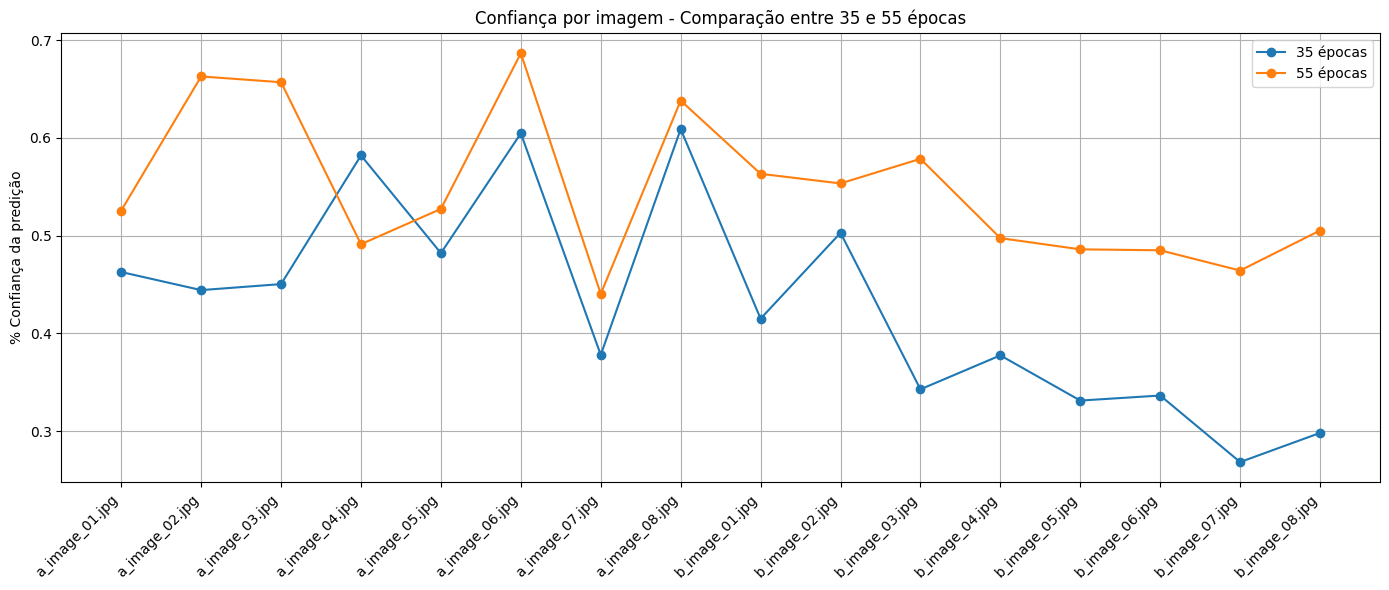

In [13]:
def datacatch(file_path):
    try:
        with open(file_path) as f:
            value = float(f.readline().split(' ')[5])
    except:
        value = 0.0
    return value

confidence_test_1 = [datacatch(f'{D1_PATH}/labels/{f.replace(".jpg",".txt")}') for f in images]
confidence_test_2 = [datacatch(f'{D2_PATH}/labels/{f.replace(".jpg",".txt")}') for f in images]

plt.figure(figsize=(14,6))
plt.plot(images, confidence_test_1, marker='o', label=f'{EPOCHS_TEST_1} épocas')
plt.plot(images, confidence_test_2, marker='o', label=f'{EPOCHS_TEST_2} épocas')
plt.xticks(rotation= 45, ha= 'right')
plt.ylabel("% Confiança da predição")
plt.title(f"Confiança por imagem - Comparação entre {EPOCHS_TEST_1} e {EPOCHS_TEST_2} épocas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### **Conclusão sobre treinos:**

##### O gráfico de linha que representa a confiança por imagem deixa evidente que ambos os modelos possuem capacidade satisfatória para detectar e distinguir os grupos de referência (AxB) por detectarem todas as imagens com indice de confiança acima de 25%, mas o treinamento com 55 épocas demonstra maior estabilidade e confiança em quase todas as imagens avaliadas, especialmente no grupo B que representa maior diversidade.
##### Em termos de recomendação para cenários de produção, a orientação básica é partir para valores entre 35 e 55 épocas (mantendo acentuada observabilidade para mitigar eventuais overfittings) a fim de ampliar a marca mínima de confiança próxima dos 40% obtidos na demonstração de melhor resultado.

#### <span style="color:#57b7b4">**5.2** Comparação visual entre deteções </span>

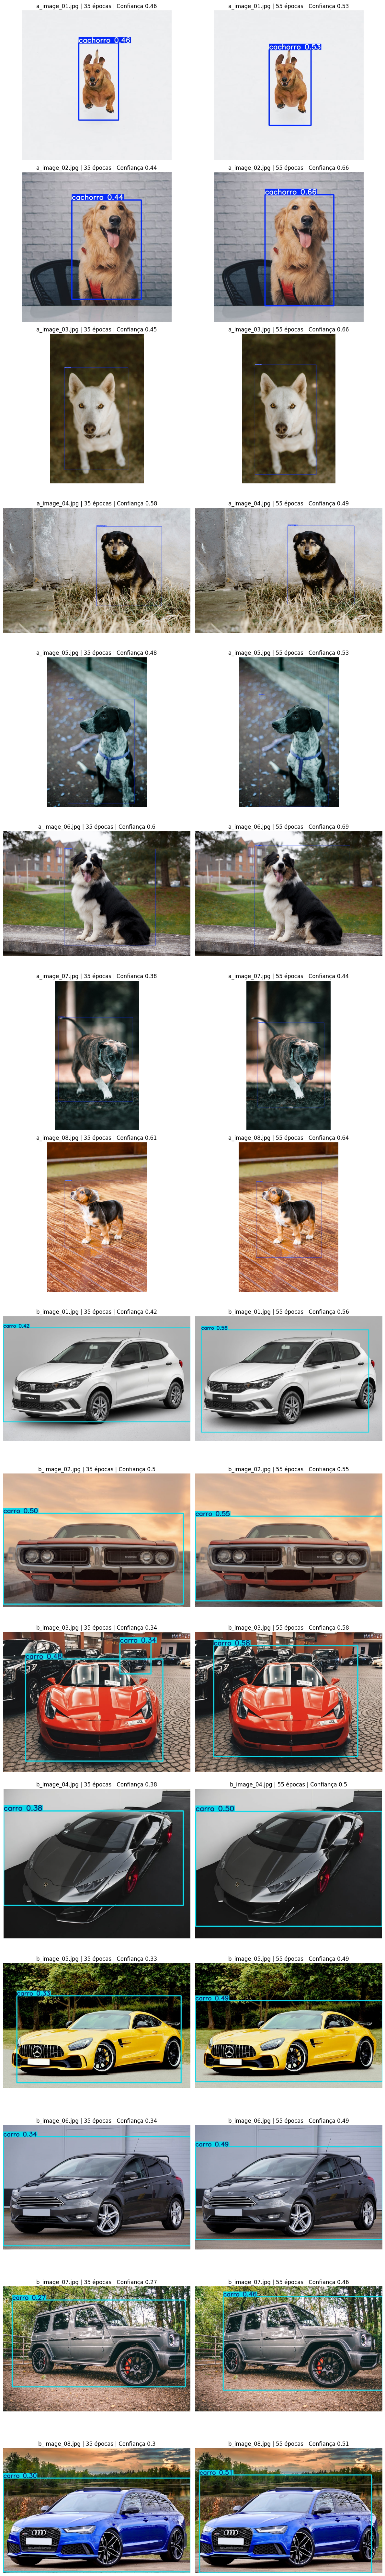

In [14]:
num_images = len(images)

fig, axes = plt.subplots(num_images, 2, figsize=(12, 5 * num_images))

for i in range(num_images):
    try:
        img_a = pil.Image.open(f'{D1_PATH}/{images[i]}')
        axes[i, 0].imshow(img_a)
        axes[i, 0].set_title(f'{images[i]} | {EPOCHS_TEST_1} épocas | Confiança {round(confidence_test_1[i], 2):}')
        axes[i, 0].axis('off')
    except:
        pass

    try:
        img_b = pil.Image.open(f'{D2_PATH}/{images[i]}')
        axes[i, 1].imshow(img_b)
        axes[i, 1].set_title(f'{images[i]} | {EPOCHS_TEST_2} épocas | Confiança {round(confidence_test_2[i], 2)}')
        axes[i, 1].axis('off')
    except:
        pass

plt.tight_layout()
plt.show()